In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [28]:
#load my datasets 
#load /home/youssef/projects/acl/Sem-09-ACL/dbs/raw/Customer_comment.csv
#load /home/youssef/projects/acl/Sem-09-ACL/dbs/raw/Survey data_Inflight Satisfaction Score.csv\
#load /home/youssef/projects/acl/Sem-09-ACL/dbs/raw/Passanger_booking_data.csv
#load /home/youssef/projects/acl/Sem-09-ACL/dbs/raw/AirlineScrappedReview_Cleaned.csv

airline_scrapped_review_cleaned : pd.DataFrame = pd.read_csv('/home/youssef/projects/acl/Sem-09-ACL/dbs/raw/AirlineScrappedReview_Cleaned.csv')
customer_comment  : pd.DataFrame = pd.read_csv('/home/youssef/projects/acl/Sem-09-ACL/dbs/raw/Customer_comment.csv')
survey_data : pd.DataFrame = pd.read_csv('/home/youssef/projects/acl/Sem-09-ACL/dbs/raw/Survey data_Inflight Satisfaction Score.csv')

passanger_booking_data : pd.DataFrame = pd.read_csv('/home/youssef/projects/acl/Sem-09-ACL/dbs/raw/Passanger_booking_data.csv')




In [3]:
##check how the data looks like

#get the head of the dataset to see how it looks like:
display(passanger_booking_data.head())

#find amount of unique values in booking_complete  and make sure no NaNs exist 
display(passanger_booking_data['booking_complete'].value_counts(dropna=False))

#make sure its a display error and route doesn't have a  \n or \r
str_1 : str =passanger_booking_data.iloc[2]['route']
str_2 : str =passanger_booking_data.iloc[0]['route']
display(len(str_1))
display(len(str_2))

#double check  for if there are any \n or \r in the route column
for _ in range(passanger_booking_data.shape[0]):
    flag_for_route_empty_space : bool = False
    if '\n' in passanger_booking_data.iloc[_]['route'] or '\r' in passanger_booking_data.iloc[_]['route']:
        display(passanger_booking_data.iloc[_]['route'])
        flag_for_route_empty_space = True
if flag_for_route_empty_space:
    display("there are some \n or \r in the route column")
else:
    display("there are no \n or \r in the route column")

#find unique locations in the route column also make sure no NaNs exist
display(passanger_booking_data['route'].unique())



,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,1,Internet,RoundTrip,21,12,6,Tue,AKLHGH,Australia,0,0,0,7.21,1
1,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
2,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
3,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
4,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0


booking_complete
0    42523
1     7479
Name: count, dtype: int64

6

6

'there are no \n or \r in the route column'

array(['AKLHGH', 'AKLDEL', 'AKLHND', 'AKLICN', 'AKLKIX', 'AKLKTM',
       'AKLKUL', 'AKLMRU', 'AKLPEK', 'AKLPVG', 'AKLTPE', 'AORICN',
       'AORKIX', 'AORKTM', 'AORMEL', 'BBIMEL', 'BBIOOL', 'BBIPER',
       'BBISYD', 'BDOCTS', 'BDOCTU', 'BDOHGH', 'BDOICN', 'BDOIKA',
       'BDOKIX', 'BDOMEL', 'BDOOOL', 'BDOPEK', 'BDOPER', 'BDOPUS',
       'BDOPVG', 'BDOSYD', 'BDOTPE', 'BDOXIY', 'BKICKG', 'BKICTS',
       'BKICTU', 'BKIHND', 'BKIICN', 'BKIKIX', 'BKIKTM', 'BKIMEL',
       'BKIMRU', 'BKIOOL', 'BKIPEK', 'BKIPER', 'BKIPUS', 'BKIPVG',
       'BKISYD', 'BKIXIY', 'BLRICN', 'BLRMEL', 'BLRPER', 'BLRSYD',
       'BOMMEL', 'BOMOOL', 'BOMPER', 'BOMSYD', 'BTJJED', 'BTUICN',
       'BTUPER', 'BTUSYD', 'BTUWUH', 'BWNCKG', 'BWNDEL', 'BWNHGH',
       'BWNIKA', 'BWNKTM', 'BWNMEL', 'BWNOOL', 'BWNPER', 'BWNSYD',
       'BWNTPE', 'CANDEL', 'CANIKA', 'CANMEL', 'CANMRU', 'CANOOL',
       'CANPER', 'CANSYD', 'CCUMEL', 'CCUMRU', 'CCUOOL', 'CCUPER',
       'CCUSYD', 'CCUTPE', 'CEBMEL', 'CEBOOL', 'CEBPER', 'CEBS

In [4]:
# get 10 most popular routes for with and without booking complete column


#get the value count of the route column
display(passanger_booking_data['route'].value_counts(dropna=False))
route_value_count = passanger_booking_data['route'].value_counts(dropna=False)

#get unique values in the route column
display(passanger_booking_data['route'].unique())

#group by and sum the num_passengers column
display(passanger_booking_data.groupby('route')['num_passengers'].sum())

routes_passangers_unverified : pd.Series = passanger_booking_data.groupby('route')['num_passengers'].sum()

#get the top 10 most popular routes
display(routes_passangers_unverified.nlargest(10))

#now do the same but for when booking_complete is true
verified_booking : pd.DataFrame = passanger_booking_data.loc[passanger_booking_data['booking_complete'] == 1]
routes_passangers_verified : pd.Series = verified_booking.groupby('route', dropna=False)['num_passengers'].sum()

#get the top 10 most popular routes
display(routes_passangers_verified.nlargest(10))

popular_routes_verified : pd.Series = routes_passangers_verified.nlargest(10)
popular_routes_unverified : pd.Series = routes_passangers_unverified.nlargest(10)



route
AKLKUL    2680
PENTPE     924
MELSGN     842
ICNSIN     801
DMKKIX     744
          ... 
HKTJED       1
KBRWUH       1
JEDMFM       1
KTMTWU       1
MRUXIY       1
Name: count, Length: 799, dtype: int64

array(['AKLHGH', 'AKLDEL', 'AKLHND', 'AKLICN', 'AKLKIX', 'AKLKTM',
       'AKLKUL', 'AKLMRU', 'AKLPEK', 'AKLPVG', 'AKLTPE', 'AORICN',
       'AORKIX', 'AORKTM', 'AORMEL', 'BBIMEL', 'BBIOOL', 'BBIPER',
       'BBISYD', 'BDOCTS', 'BDOCTU', 'BDOHGH', 'BDOICN', 'BDOIKA',
       'BDOKIX', 'BDOMEL', 'BDOOOL', 'BDOPEK', 'BDOPER', 'BDOPUS',
       'BDOPVG', 'BDOSYD', 'BDOTPE', 'BDOXIY', 'BKICKG', 'BKICTS',
       'BKICTU', 'BKIHND', 'BKIICN', 'BKIKIX', 'BKIKTM', 'BKIMEL',
       'BKIMRU', 'BKIOOL', 'BKIPEK', 'BKIPER', 'BKIPUS', 'BKIPVG',
       'BKISYD', 'BKIXIY', 'BLRICN', 'BLRMEL', 'BLRPER', 'BLRSYD',
       'BOMMEL', 'BOMOOL', 'BOMPER', 'BOMSYD', 'BTJJED', 'BTUICN',
       'BTUPER', 'BTUSYD', 'BTUWUH', 'BWNCKG', 'BWNDEL', 'BWNHGH',
       'BWNIKA', 'BWNKTM', 'BWNMEL', 'BWNOOL', 'BWNPER', 'BWNSYD',
       'BWNTPE', 'CANDEL', 'CANIKA', 'CANMEL', 'CANMRU', 'CANOOL',
       'CANPER', 'CANSYD', 'CCUMEL', 'CCUMRU', 'CCUOOL', 'CCUPER',
       'CCUSYD', 'CCUTPE', 'CEBMEL', 'CEBOOL', 'CEBPER', 'CEBS

route
AKLDEL     33
AKLHGH      2
AKLHND      4
AKLICN    102
AKLKIX     10
         ... 
TRZWUH     14
TRZXIY      8
TWUWUH      4
TWUXIY     11
URTXIY      2
Name: num_passengers, Length: 799, dtype: int64

route
AKLKUL    4450
PENTPE    1566
DMKKIX    1428
ICNSIN    1335
MELSGN    1230
DPSICN    1192
ICNSYD     997
MELPEN     942
COKSYD     932
DPSPVG     932
Name: num_passengers, dtype: int64

route
AKLKUL    965
PENTPE    697
DMKKIX    374
ICNPEN    223
MELPEN    209
CTSDMK    201
JHBKTM    188
DPSPVG    186
BKIICN    182
CGKHND    182
Name: num_passengers, dtype: int64

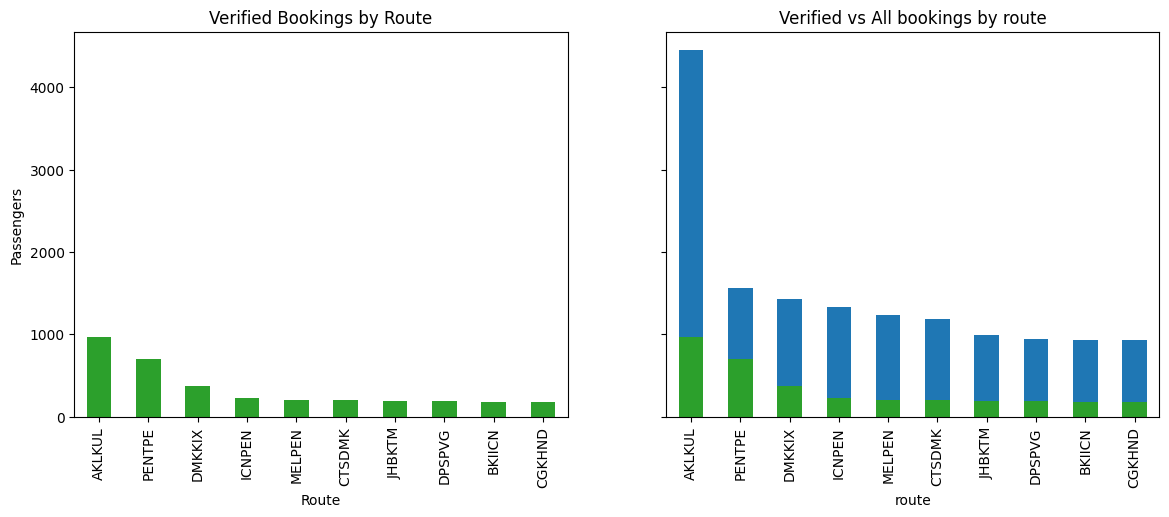

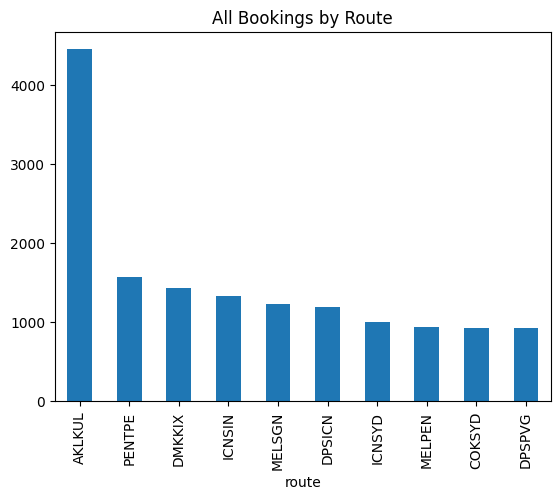

In [ ]:
#i am working under the assumption that since only this dataset contains the route column and the questions states explicitly about 10 most popular flight routes and then asks about the distribution of bookings across flight hours so because of that i will assume they only want the passanger booking data dataset 

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Change: verified Green, unverified Blue
popular_routes_verified.plot(kind='bar', ax=axes[0], color='tab:green')
axes[0].set_title('Verified Bookings by Route')
axes[0].set_xlabel('Route')
axes[0].set_ylabel('Passengers')

popular_routes_unverified.plot(kind='bar', ax=axes[1], color='tab:blue')
axes[1].set_title('All Bookings by Route')
axes[1].set_xlabel('Route')




# Again, set colors to green and blue as above
popular_routes_verified.plot(kind='bar', color='tab:green', title='Verified vs All bookings by route')
plt.show()

popular_routes_unverified.plot(kind='bar', color='tab:blue', title='All Bookings by Route')
plt.show()










In [ ]:
#distribution of bookings across flight hours  using a histogram for verified and unverified bookings 

unique_values_flight_hours : pd.Series = passanger_booking_data['flight_hour'].unique()
display(unique_values_flight_hours)

## we need to group by flight_hour and sum the num_passengers column
passangers_per_flight_hour_unverified : pd.Series = passanger_booking_data.groupby('flight_hour')['num_passengers'].sum()

## remember we have 2 dataframes for verified and unverified bookings ; verified_booking 

passangers_per_flight_hour_verified : pd.Series = verified_booking.groupby('flight_hour')['num_passengers'].sum()

display(passangers_per_flight_hour_verified)
display(passangers_per_flight_hour_unverified)

##now we need to plot the data using a histogram for verified and unverified bookings  each one seperately


array([ 6,  7,  3, 17,  4, 15, 20, 14, 12,  2, 19, 10,  8, 23,  9, 13, 11,
        0,  1,  5, 16, 18, 22, 21])

flight_hour
0     272
1     485
2     634
3     646
4     685
5     700
6     828
7     678
8     784
9     861
10    674
11    664
12    734
13    804
14    857
15    680
16    496
17    300
18    140
19     54
20     40
21     60
22     93
23    170
Name: num_passengers, dtype: int64

flight_hour
0     2382
1     3287
2     4073
3     4219
4     4473
5     4492
6     4786
7     4910
8     5096
9     5021
10    4877
11    4940
12    5027
13    4905
14    4692
15    3743
16    2582
17    1470
18     720
19     449
20     425
21     592
22     879
23    1526
Name: num_passengers, dtype: int64

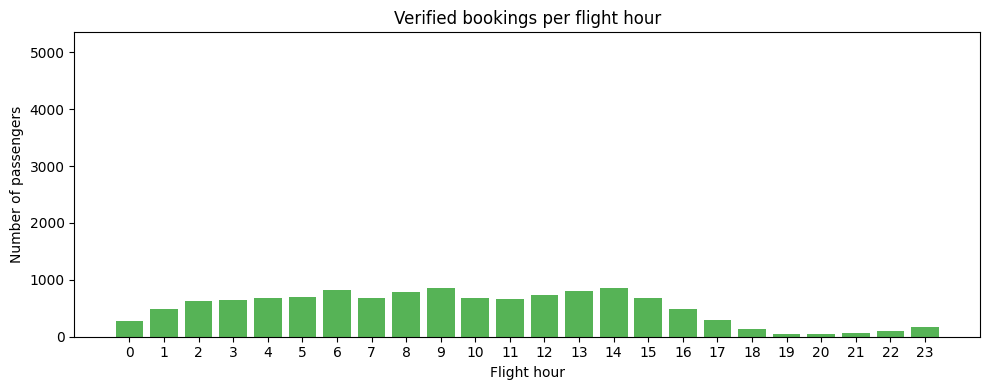

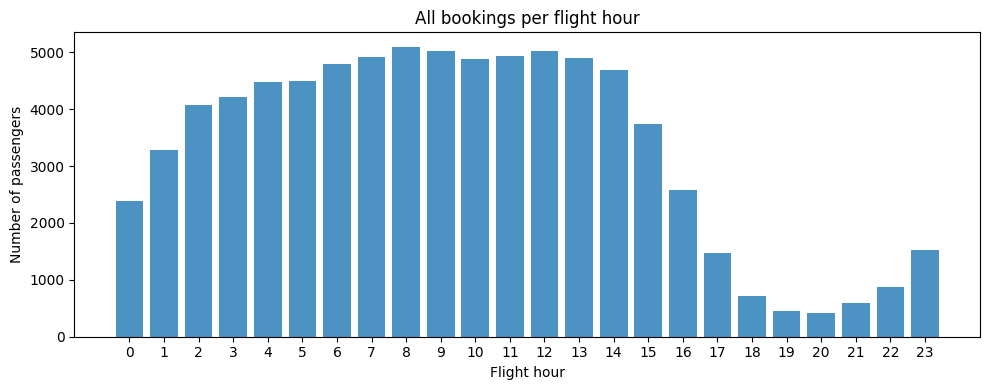

In [ ]:
###time to plot the data using a histogram for verified and unverified bookigns BABYYY

##make both plots y axis have the same range

##i am working under the assumption that since only this dataset has flight_hour column i will  use it exclusively to plot the data

# Calculate y-axis upper limit as the max of both datasets
max_passengers = max(
    passangers_per_flight_hour_verified.max(),
    passangers_per_flight_hour_unverified.max()
)

plt.figure(figsize=(10, 4))
plt.bar(
    passangers_per_flight_hour_verified.index,
    passangers_per_flight_hour_verified.values,
    color="#2ca02c",
    alpha=0.8
)
plt.title("Verified bookings per flight hour")
plt.xlabel("Flight hour")
plt.ylabel("Number of passengers")
plt.xticks(range(24))
plt.ylim(0, max_passengers * 1.05)  # Add a little headroom
plt.tight_layout()
plt.show()

# Plot unverified bookings
plt.figure(figsize=(10, 4))
plt.bar(
    passangers_per_flight_hour_unverified.index,
    passangers_per_flight_hour_unverified.values,
    color="#1f77b4",
    alpha=0.8
)
plt.title("All bookings per flight hour")
plt.xlabel("Flight hour")
plt.ylabel("Number of passengers")
plt.xticks(range(24))
plt.ylim(0, max_passengers * 1.05)
plt.tight_layout()
plt.show()


In [31]:
###check which datasets would match the question of which traveler type and traveller_class combination yields the highest and lowest ratings   



display(airline_scrapped_review_cleaned.columns)
display(passanger_booking_data.columns)
display(customer_comment.columns)
display(survey_data.columns)
##understand the data
display(customer_comment.head())
display(survey_data.head())

display(customer_comment['flight_number'].unique())
display(survey_data['flight_number'].unique())


##### i don't beleive for the which traveler type and traveller_class combination yields the highest and lowest ratings i need anything other then the airlinescrappedreview_cleaned dataset based on the findings in the previous cells 













Index(['Passanger_Name', 'Flying_Date', 'Route', 'Rating', 'Verified',
       'Review_title', 'Review_content', 'Traveller_Type', 'Class',
       'Start_Location', 'End_Location', 'Layover_Route', 'Start_Latitude',
       'Start_Longitude', 'Start_Address', 'End_Latitude', 'End_Longitude',
       'End_Address'],
      dtype='object')

Index(['num_passengers', 'sales_channel', 'trip_type', 'purchase_lead',
       'length_of_stay', 'flight_hour', 'flight_day', 'route',
       'booking_origin', 'wants_extra_baggage', 'wants_preferred_seat',
       'wants_in_flight_meals', 'flight_duration', 'booking_complete'],
      dtype='object')

Index(['Unnamed: 0', 'flight_number', 'origin_station_code',
       'destination_station_code', 'scheduled_departure_date',
       'arrival_delay_group', 'departure_delay_group', 'entity',
       'verbatim_text', 'seat_factor_band', 'ques_verbatim_text',
       'loyalty_program_level', 'fleet_type_description', 'fleet_usage',
       'response_group', 'sentiments', 'transformed_text'],
      dtype='object')

Index(['flight_number', 'origin_station_code', 'destination_station_code',
       'record_locator', 'scheduled_departure_date', 'question_text', 'score',
       'satisfaction_type', 'driver_sub_group1', 'driver_sub_group2',
       'arrival_delay_minutes', 'arrival_delay_group', 'cabin_code_desc',
       'cabin_name', 'entity', 'number_of_legs', 'seat_factor_band',
       'loyalty_program_level', 'generation', 'fleet_type_description',
       'fleet_usage', 'equipment_type_code', 'ua_uax', 'actual_flown_miles',
       'haul_type', 'departure_gate', 'arrival_gate',
       'international_domestic_indicator', 'response_group', 'media_provider',
       'hub_spoke'],
      dtype='object')

,Unnamed: 0,flight_number,origin_station_code,destination_station_code,scheduled_departure_date,arrival_delay_group,departure_delay_group,entity,verbatim_text,seat_factor_band,ques_verbatim_text,loyalty_program_level,fleet_type_description,fleet_usage,response_group,sentiments,transformed_text
0,0,950,LHX,SFX,2022-09-01,Early & Ontime,Delayed,Atlantic,There was no salad dressing. The staff informe...,0 to 70,Is there anything else you'd like to share abo...,non-elite,B777-200,Mainline,member,Neutral,salad dress staff inform flight receiv salad d...
1,1,950,LHX,SFX,2022-09-01,Early & Ontime,Delayed,Atlantic,Not a choice.,0 to 70,Is there anything else you'd like to share abo...,NaN,B777-200,Mainline,non-member,Neutral,choic
2,2,1876,FLX,EWX,2022-09-01,Early & Ontime,Early & Ontime,Domestic,More variety and bigger snacks.,90+,Is there anything else you'd like to share abo...,non-elite,A320-200,Mainline,member,Neutral,varieti bigger snack
3,3,5469,SFX,SEX,2022-09-01,Early & Ontime,Early & Ontime,Domestic,Serving pretzels and cookies in first class wa...,90+,Is there anything else you'd like to share abo...,premier gold,ERJ-175,Express,member,Neutral,serv pretzel cooki first class extrem disappoi...
4,4,281,DEX,ANX,2022-09-01,Early & Ontime,Early & Ontime,Domestic,More inflight selections to purchase for full ...,0 to 70,Is there anything else you'd like to share abo...,non-elite,B737-MAX8,Mainline,member,Neutral,inflight select purchas full meal


,flight_number,origin_station_code,destination_station_code,record_locator,scheduled_departure_date,question_text,score,satisfaction_type,driver_sub_group1,driver_sub_group2,...,equipment_type_code,ua_uax,actual_flown_miles,haul_type,departure_gate,arrival_gate,international_domestic_indicator,response_group,media_provider,hub_spoke
0,3802,MKX,ORX,CYXXJJ,9/1/2022,How satisfied were you with the food & beverag...,2,Dissatisfied,food & beverage,food and beverage satisfaction,...,CRZ,UAX,67,Short,C12,F10,Domestic,non-member,NaN,spoke departure
1,4645,COX,DEX,DRXXMH,9/1/2022,How satisfied were you with the food & beverag...,5,Satisfied,food & beverage,food and beverage satisfaction,...,E75,UAX,72,Short,5,B60,Domestic,member,GOGO,spoke departure
2,5236,COX,DEX,DEXXS1,9/1/2022,How satisfied were you with the food & beverag...,5,Satisfied,food & beverage,food and beverage satisfaction,...,E75,UAX,72,Short,7,A71,Domestic,member,GOGO,spoke departure
3,4686,DEX,COX,PXXXLH,9/1/2022,How satisfied were you with the food & beverag...,3,Dissatisfied,food & beverage,food and beverage satisfaction,...,CRJ,UAX,72,Short,B82,5,Domestic,member,NaN,hub departure
4,671,DEX,COX,KZXXH5,9/1/2022,How satisfied were you with the food & beverag...,5,Satisfied,food & beverage,food and beverage satisfaction,...,19F,UA,72,Short,B24,3,Domestic,member,PANASONIC,hub departure


array([ 950, 1876, 5469, ..., 4720, 3612, 1877], shape=(3001,))

array([3802, 4645, 5236, ..., 5430, 2074, 1550], shape=(4058,))

array(['Solo Leisure', 'Couple Leisure', 'Family Leisure', 'Business',
       'Unknown', 'Various'], dtype=object)

array(['Economy Class', 'Business Class', 'Premium Economy',
       'First Class', 'Unknown'], dtype=object)

array([ 1,  2,  4,  7,  3,  9, 10,  5,  8,  6])

array(['Solo Leisure', 'Couple Leisure', 'Family Leisure', 'Business'],
      dtype=object)

array(['Economy Class', 'Business Class', 'Premium Economy',
       'First Class'], dtype=object)

Traveller_Type  Class          
Business        Business Class     3.510791
                Economy Class      3.457031
                First Class        4.270270
                Premium Economy    3.750000
Couple Leisure  Business Class     5.332335
                Economy Class      3.908297
                First Class        5.983607
                Premium Economy    4.239583
Family Leisure  Business Class     5.743902
                Economy Class      4.061069
                First Class        4.230769
                Premium Economy    3.600000
Solo Leisure    Business Class     5.780347
                Economy Class      4.631193
                First Class        6.627907
                Premium Economy    5.653061
Name: Rating, dtype: float64

Traveller_Type  Class      
Solo Leisure    First Class    6.627907
Name: Rating, dtype: float64

Traveller_Type  Class        
Business        Economy Class    3.457031
Name: Rating, dtype: float64

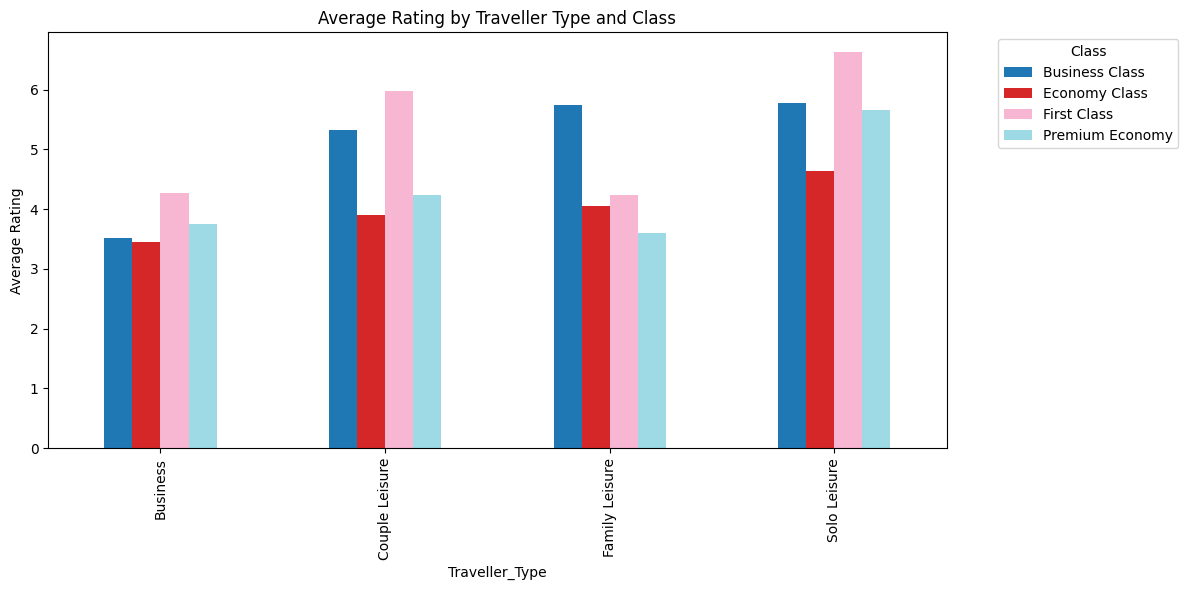

In [41]:
###make sure no NaNs exist in the cells i want traveler_type and traveller_class and rating
display(airline_scrapped_review_cleaned['Traveller_Type'].unique())
display(airline_scrapped_review_cleaned['Class'].unique())
display(airline_scrapped_review_cleaned['Rating'].unique())

#remove values that are written as Unknown or Various in the Traveller_Type column
airline_scrapped_review_cleaned_filtered : pd.DataFrame = airline_scrapped_review_cleaned[airline_scrapped_review_cleaned['Traveller_Type'] != 'Unknown' ]
airline_scrapped_review_cleaned_filtered = airline_scrapped_review_cleaned_filtered[airline_scrapped_review_cleaned_filtered['Traveller_Type'] != 'Various']

display(airline_scrapped_review_cleaned_filtered['Traveller_Type'].unique())

#remove values that are written as Unknown in the Class column
airline_scrapped_review_cleaned_filtered = airline_scrapped_review_cleaned_filtered[airline_scrapped_review_cleaned_filtered['Class'] != 'Unknown']

display(airline_scrapped_review_cleaned_filtered['Class'].unique())

## group by traveller_type and class and get the mean of the rating column

airline_scrapped_review_cleaned_filtered_grouped : pd.DataFrame = airline_scrapped_review_cleaned_filtered.groupby(['Traveller_Type', 'Class'])['Rating'].mean()

display(airline_scrapped_review_cleaned_filtered_grouped)


##get the overall highest and lowest traveller_type and class combination
display(airline_scrapped_review_cleaned_filtered_grouped.nlargest(1))
display(airline_scrapped_review_cleaned_filtered_grouped.nsmallest(1))



# Visualize the mean ratings by Traveller_Type and Class in a bar plot
airline_scrapped_review_cleaned_filtered_grouped.unstack().plot(
    kind='bar',
    figsize=(12,6),
    colormap='tab20'
)
plt.ylabel('Average Rating')
plt.title('Average Rating by Traveller Type and Class')
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
























